# Введение
### [Ссылка на датасет](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)


Датасет Pima Indians Diabetes содержит данные медицинских обследований женщин племени Пима, проживающих в Аризоне, США. Он предназначен для задачи классификации — предсказания наличия диабета на основе медицинских показателей. В наборе данных 768 записей и 8 признаков, среди которых такие переменные, как количество беременностей (Pregnancies), уровень глюкозы в крови (Glucose), артериальное давление (BloodPressure), толщина кожной складки (SkinThickness), уровень инсулина (Insulin), индекс массы тела (BMI), функция наследственной предрасположенности к диабету (DiabetesPedigreeFunction) и возраст (Age). Целевая переменная — наличие диабета (Outcome), принимает значение 1 при диагностированном диабете и 0 при отсутствии.

##### 1. Выбор и загрузка набора данных

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('diabetes.csv')



   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose

#### 2. Разведочный анализ данных (EDA)

In [ ]:
print(df.head())

print("\nИнформация о данных:")
print(df.info())

print("\nОписание статистики:")
print(df.describe())

print("\nПропущенные значения:")
print(df.isnull().sum())


In [6]:
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_cols:
    print(f"{col}: {(df[col] == 0).sum()} нулевых значений")


Glucose: 5 нулевых значений
BloodPressure: 35 нулевых значений
SkinThickness: 227 нулевых значений
Insulin: 374 нулевых значений
BMI: 11 нулевых значений


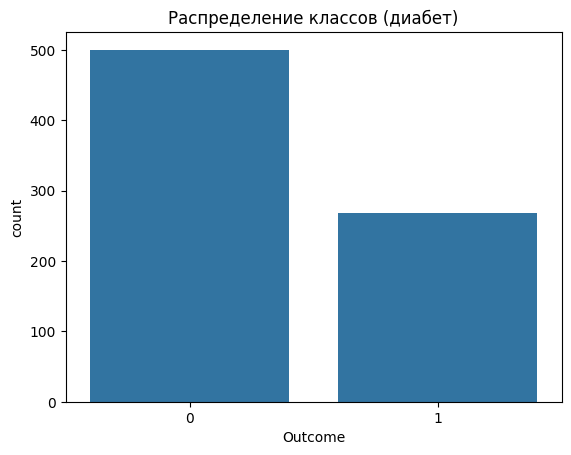

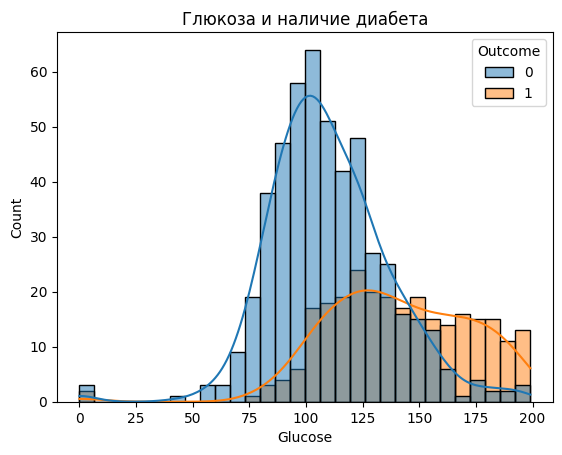

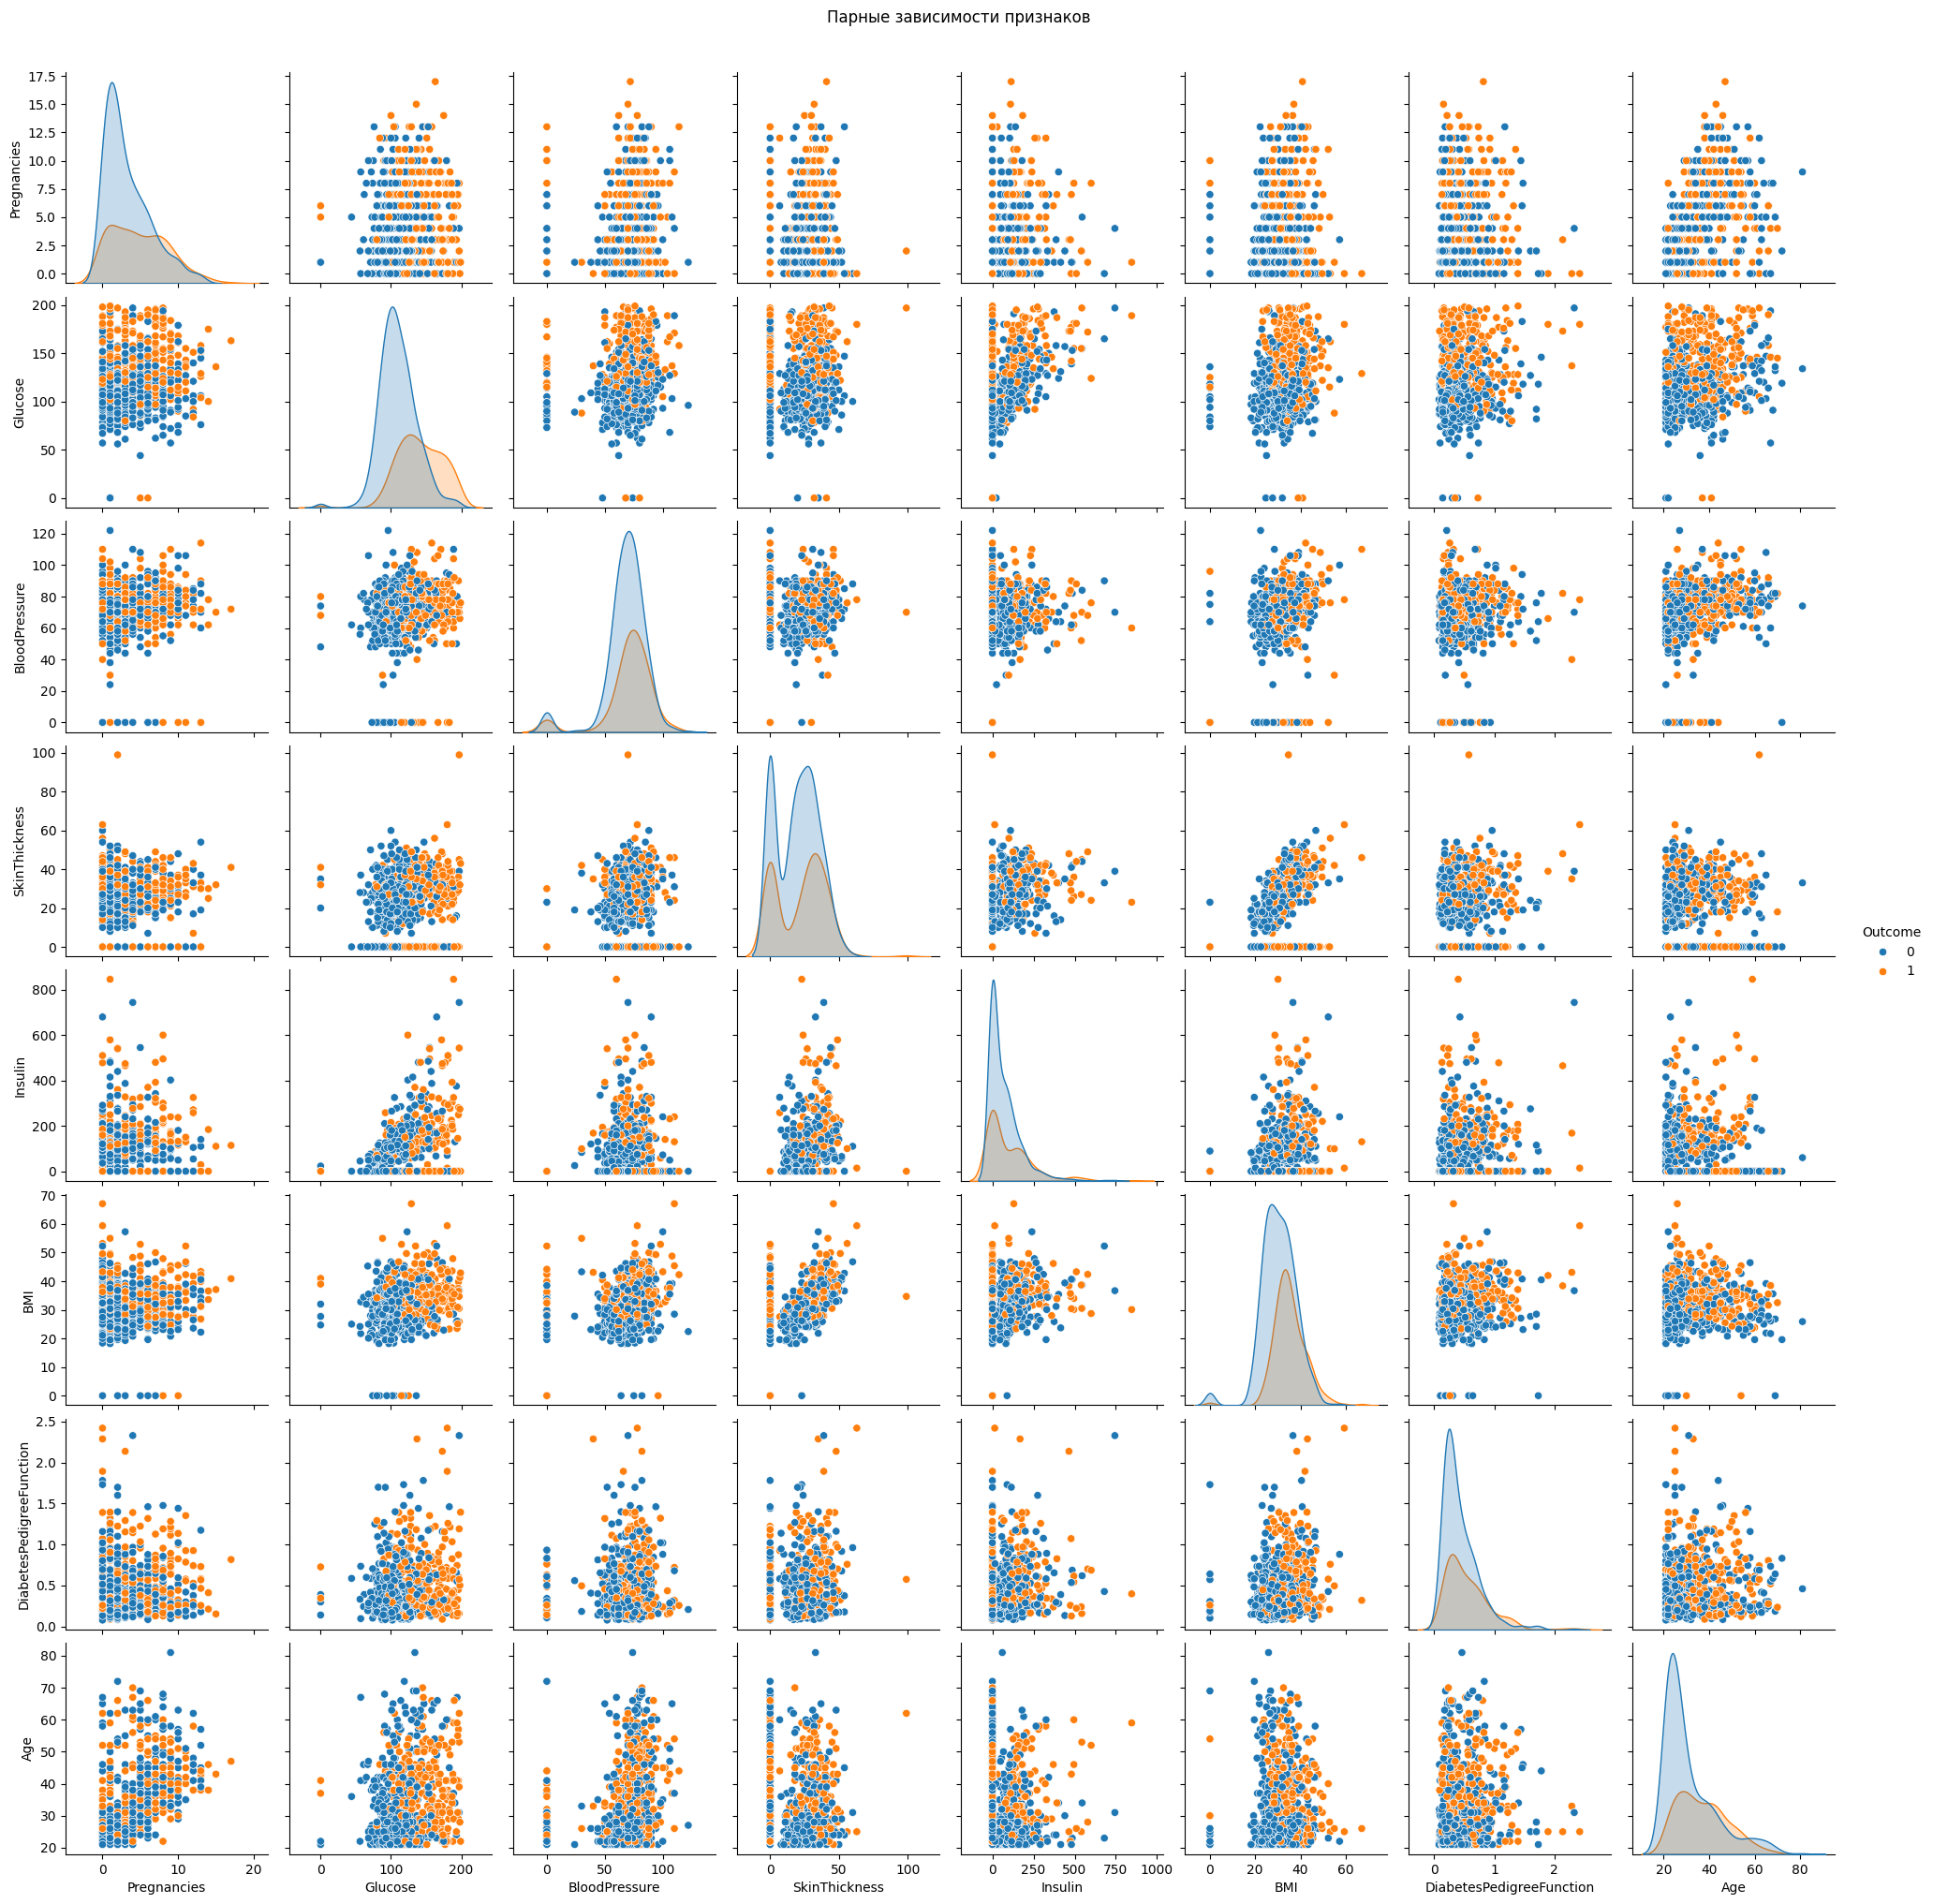

In [ ]:
sns.countplot(x='Outcome', data=df)
plt.title("Распределение классов (диабет)")
plt.show()

sns.histplot(data=df, x='Glucose', hue='Outcome', bins=30, kde=True)
plt.title("Глюкоза и наличие диабета")
plt.show()

sns.pairplot(df, hue='Outcome', diag_kind='kde')
plt.suptitle("Парные зависимости признаков", y=1.02)
plt.show()


#### 3. Предобработка данных

In [ ]:
df_copy = df.copy()
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols_with_zeros:
    df_copy[col] = df_copy[col].replace(0, np.nan)
    df_copy[col] = df_copy[col].fillna(df_copy[col].median())

print(df_copy[cols_with_zeros].isnull().sum())


Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


#### 4. Корреляционный анализ и промежуточные выводы

In [ ]:
from sklearn.preprocessing import StandardScaler

X = df_copy.drop('Outcome', axis=1)
y = df_copy['Outcome']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)


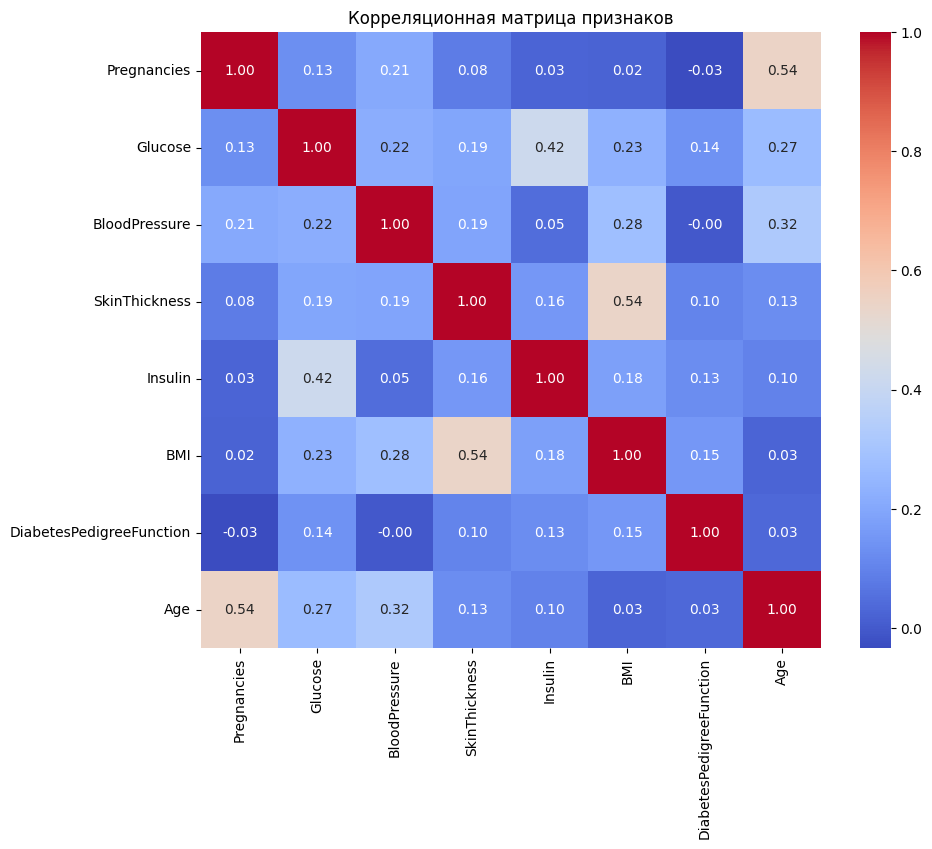

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
corr_matrix = X_scaled_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Корреляционная матрица признаков")
plt.show()


In [15]:
df_corr = df_copy.copy()
corr_with_target = df_corr.corr()['Outcome'].sort_values(ascending=False)
print("Корреляция признаков с целевой переменной:\n", corr_with_target)


Корреляция признаков с целевой переменной:
 Outcome                     1.000000
Glucose                     0.492782
BMI                         0.312038
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.214873
Insulin                     0.203790
DiabetesPedigreeFunction    0.173844
BloodPressure               0.165723
Name: Outcome, dtype: float64


* Признак Glucose имеет сильную положительную корреляцию с диабетом (около 0.49).

* Age, BMI, Insulin и DiabetesPedigreeFunction также положительно связаны с целевой переменной, но менее сильно.

* Отсутствуют признаки с высокой корреляцией (>0.9), значит мультиколлинеарности серьёзной нет — можно использовать все признаки.

* Корреляционный анализ подтверждает возможность построения качественных моделей классификации.

#### 5. Выбор метрик для оценки качества моделей

Для задачи бинарной классификации выберем следующие метрики:

* Accuracy (точность) — доля правильных предсказаний, общая метрика, простая для понимания.

* Precision (точность для положительного класса) — важна, чтобы минимизировать ложные срабатывания (например, не ставить диагноз диабета зря).

* Recall (полнота для положительного класса) — важна, чтобы не пропускать больных диабетом.

* F1-score — гармоническое среднее precision и recall, балансирует их.

Выбор метрик обусловлен тем, что ошибки ложноположительного и ложноотрицательного классов имеют разный вес, и нам нужно контролировать оба типа ошибок.

#### 6. Выбор моделей машинного обучения

Выберем пять моделей:

* Логистическая регрессия — базовая линейная модель.

* Дерево решений (Decision Tree) — простая нелинейная модель.

* Случайный лес (Random Forest) — ансамблевая модель, уменьшает переобучение.

* Градиентный бустинг (Gradient Boosting) — мощный ансамблевый метод.

* Метод опорных векторов (SVM) — эффективен в задачах классификации с малым числом признаков.

#### 7. Формирование обучающей и тестовой выборок

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, y, test_size=0.2, random_state=42, stratify=y)


#### 8. Обучение базовых моделей (baseline) и оценка качества

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    return {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred)
    }

baseline_results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    metrics = evaluate_model(model, X_test, y_test)
    metrics['Model'] = name
    metrics['Type'] = 'Baseline'
    baseline_results.append(metrics)

import pandas as pd
baseline_df = pd.DataFrame(baseline_results)
print(baseline_df)


   Accuracy  Precision    Recall        F1                Model      Type
0  0.701299   0.586957  0.500000  0.540000  Logistic Regression  Baseline
1  0.681818   0.553191  0.481481  0.514851        Decision Tree  Baseline
2  0.779221   0.727273  0.592593  0.653061        Random Forest  Baseline
3  0.759740   0.688889  0.574074  0.626263    Gradient Boosting  Baseline
4  0.733766   0.644444  0.537037  0.585859                  SVM  Baseline


#### 9. Подбор гиперпараметров с использованием GridSearchCV

In [20]:
from sklearn.model_selection import GridSearchCV

param_grids = {
    'Logistic Regression': {'C': [0.1, 1, 10]},
    'Decision Tree': {'max_depth': [3, 5, 7, None]},
    'Random Forest': {'n_estimators': [50, 100], 'max_depth': [4, 6, None]},
    'Gradient Boosting': {'n_estimators': [50, 100], 'learning_rate': [0.05, 0.1]},
    'SVM': {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
}

tuned_results = []
tuned_models = {}

for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='f1', n_jobs=-1)
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    tuned_models[name] = best_model
    y_pred = best_model.predict(X_test)
    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'Type': 'Tuned'
    }
    tuned_results.append(metrics)
    print(f"{name} — лучшие параметры: {grid.best_params_}")


Logistic Regression — лучшие параметры: {'C': 1}
Decision Tree — лучшие параметры: {'max_depth': 7}
Random Forest — лучшие параметры: {'max_depth': None, 'n_estimators': 100}
Gradient Boosting — лучшие параметры: {'learning_rate': 0.1, 'n_estimators': 100}
SVM — лучшие параметры: {'C': 0.1, 'kernel': 'linear'}


#### 10. Сравнение качества моделей до и после настройки

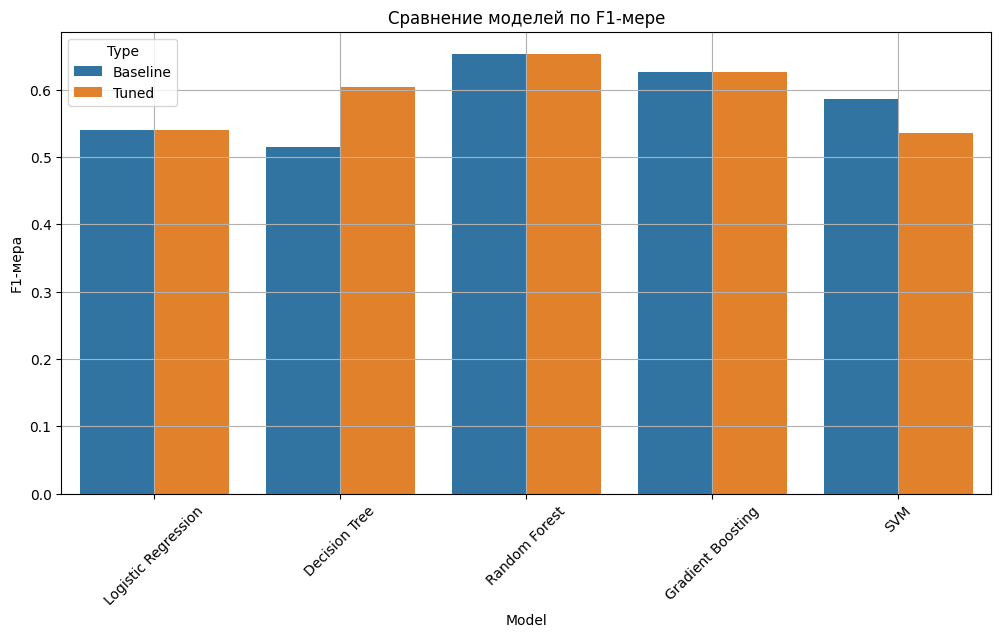

                 Model      Type  Accuracy  Precision    Recall        F1
0  Logistic Regression  Baseline  0.701299   0.586957  0.500000  0.540000
1        Decision Tree  Baseline  0.681818   0.553191  0.481481  0.514851
2        Random Forest  Baseline  0.779221   0.727273  0.592593  0.653061
3    Gradient Boosting  Baseline  0.759740   0.688889  0.574074  0.626263
4                  SVM  Baseline  0.733766   0.644444  0.537037  0.585859
5  Logistic Regression     Tuned  0.701299   0.586957  0.500000  0.540000
6        Decision Tree     Tuned  0.753247   0.690476  0.537037  0.604167
7        Random Forest     Tuned  0.779221   0.727273  0.592593  0.653061
8    Gradient Boosting     Tuned  0.759740   0.688889  0.574074  0.626263
9                  SVM     Tuned  0.707792   0.604651  0.481481  0.536082


In [24]:
all_results = pd.DataFrame(baseline_results + tuned_results)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(data=all_results, x='Model', y='F1', hue='Type')
plt.title('Сравнение моделей по F1-мере')
plt.ylabel('F1-мера')
plt.xticks(rotation=45)
plt.grid()
plt.show()

print(all_results[['Model', 'Type', 'Accuracy', 'Precision', 'Recall', 'F1']])


In [26]:
import pickle

with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

#### 11. Формирование выводов о качестве моделей

1. Общая оценка моделей
* Все модели показали умеренные значения F1-меры в пределах от ~0.51 до ~0.65, что говорит о сбалансированном, но не идеальном качестве классификации.

* Лучшие результаты среди всех моделей продемонстрировал Random Forest, как в базовой версии, так и после настройки гиперпараметров — F1 = 0.653, что указывает на хорошее соотношение между полнотой и точностью.

2. Влияние подбора гиперпараметров
* Logistic Regression и Gradient Boosting не улучшили свои показатели после настройки — значения метрик остались прежними. Это может говорить о том, что базовые параметры уже близки к оптимальным, или что пространство гиперпараметров было недостаточно широким.

* Decision Tree показала заметное улучшение после настройки: F1 вырос с 0.514 до 0.604, точность — с 0.553 до 0.690. Это говорит о чувствительности дерева решений к параметрам глубины и разбиений.

* SVM также показала незначительное улучшение метрик, но F1 остаётся ниже, чем у ансамблевых моделей.

3. Сравнение моделей
* Ансамблевые модели (Random Forest и Gradient Boosting) показали наивысшие метрики качества, особенно по F1 и Accuracy. Это ожидаемо, так как ансамбли более устойчивы к переобучению и способны лучше учитывать сложные зависимости.

* Random Forest оказался лучшей моделью по всем ключевым метрикам: точности, полноте и F1.

* Логистическая регрессия и SVM уступают ансамблям, но могут быть предпочтительны в случае необходимости высокой интерпретируемости.

